# Tropycal quickstart — one Atlantic season

Fetch tropical-cyclone **best tracks** for the 2005 North Atlantic season from HURDAT2 through the `earthlens` Tropycal backend and plot them coloured by Saffir-Simpson category.

Tropycal is a `vector` backend: `download()` returns a pyramids `FeatureCollection` (a `geopandas.GeoDataFrame`). The default geometry is one `Point` per 6-hourly fix.

> **First-load cost.** The first query of a basin downloads and parses its whole best-track file (a few seconds for HURDAT, longer for IBTrACS). Needs `pip install earthlens[tropycal]`.

In [1]:
from pathlib import Path

from earthlens import EarthLens

OUT_DIR = Path('tropycal_output')
OUT_DIR.mkdir(exist_ok=True)

## Query

`variables` selects the **basin** (here `north_atlantic`). The whole season's storms are filtered to the date window and bbox at the fix level. The result is written to `tropycal_output/` and returned in memory.

In [2]:
# Live best-track query. Wrapped so the notebook stays safe under
# nbval-lax when run offline / without the [tropycal] extra.
fixes = None
try:
    fixes = EarthLens(
        variables=['north_atlantic'],
        data_source='tropycal',
        start='2005-08-01',
        end='2005-09-15',
        aoi=[-98.0, 18.0, -80.0, 31.0],
        source='hurdat',
        path=str(OUT_DIR),
    ).download(progress_bar=False)
    print(len(fixes), 'fixes')
except Exception as exc:
    print(f'skipped live query: {type(exc).__name__}: {exc}')

2026-05-23 18:04:16 | INFO | pyramids.base.config | Logging is configured.


C:\python-environments\pixi\envs\earthlens-7782220113782294872\envs\dev\Lib\site-packages\tropycal\_version.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


2026-05-23 18:04:19.061 | INFO     | earthlens.tropycal.backend:_get_track_dataset:378 - Loading tropycal TrackDataset(basin='north_atlantic', source='hurdat'); the first load downloads + parses the whole basin best-track file and can be slow.


--> Starting to read in HURDAT2 data


--> Completed reading in HURDAT2 data (3.47 seconds)


2026-05-23 18:04:33 | INFO | pyogrio._io | Created 24 records


2026-05-23 18:04:33.569 | INFO     | earthlens.tropycal.backend:download:514 - Tropycal download summary: 24 feature(s) across 1 file(s) written to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\tropycal\docs\examples\tropycal\tropycal_output


24 fixes


## Inspect the fixes

In [3]:
if fixes is not None and len(fixes):
    cols = ['storm_id', 'name', 'time', 'vmax_kt', 'category', 'geometry']
    display(fixes[cols].head())
    print('CRS:', fixes.crs)

,storm_id,name,time,vmax_kt,category,geometry
0,AL112005,JOSE,2005-08-22 12:00:00+00:00,30.0,0,POINT (-94.5 19.4)
1,AL112005,JOSE,2005-08-22 18:00:00+00:00,35.0,0,POINT (-95 19.6)
2,AL112005,JOSE,2005-08-23 00:00:00+00:00,45.0,0,POINT (-95.7 19.7)
3,AL112005,JOSE,2005-08-23 03:30:00+00:00,50.0,0,POINT (-96.4 19.7)
4,AL112005,JOSE,2005-08-23 06:00:00+00:00,35.0,0,POINT (-96.7 19.7)


CRS: EPSG:4326


## Plot the track fixes coloured by category

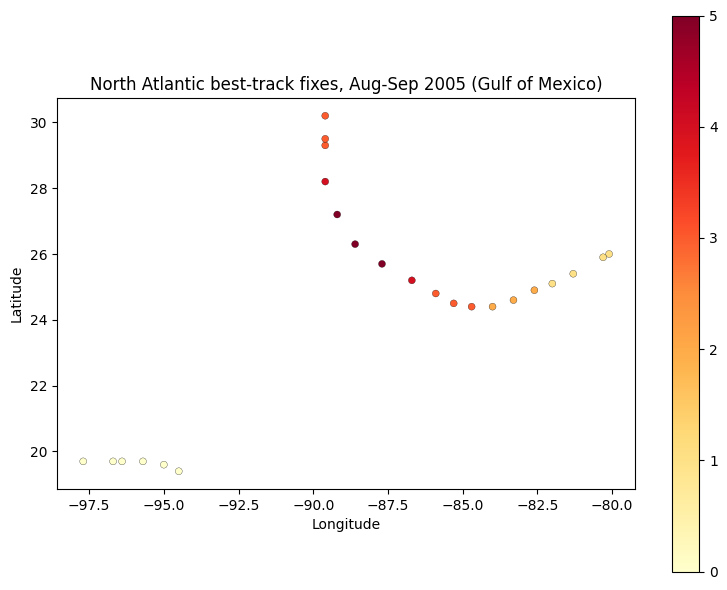

In [4]:
if fixes is not None and len(fixes):
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(8, 6))
    fixes.plot(ax=ax, column='category', cmap='YlOrRd', legend=True,
               markersize=25, edgecolor='k', linewidth=0.2)
    ax.set_title('North Atlantic best-track fixes, Aug-Sep 2005 (Gulf of Mexico)')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.tight_layout()
    plt.show()